Dataset Found At:
/kaggle/input/datasets/anshkhandelwal22/unsupervised-learning/Country-data.csv

Dataset Shape:
(167, 10)

Columns:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

First 5 Rows:
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  

Missing Values:
country       0


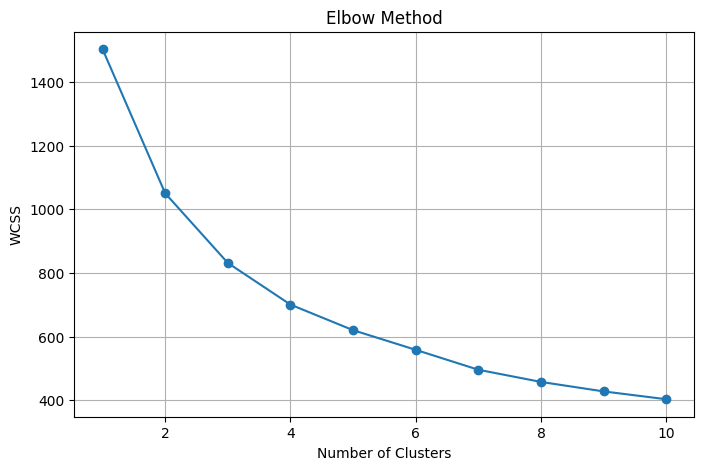


Silhouette Scores
K = 2 --> Score = 0.2874
K = 3 --> Score = 0.2833
K = 4 --> Score = 0.2960
K = 5 --> Score = 0.2993
K = 6 --> Score = 0.2287
K = 7 --> Score = 0.2477
K = 8 --> Score = 0.2388
K = 9 --> Score = 0.2073
K = 10 --> Score = 0.2022

Best K: 5
Best Silhouette Score: 0.2993

Cluster Counts:
Cluster
0    84
1    47
3    32
2     3
4     1
Name: count, dtype: int64

Explained Variance Ratio:
[0.4595174  0.17181626]


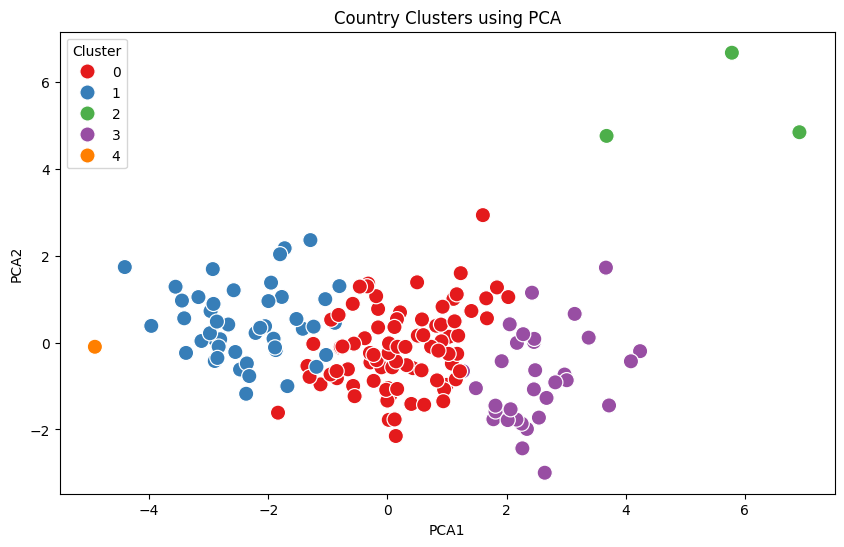


Cluster Summary:
         child_mort     exports    health     imports        income  \
Cluster                                                               
0         21.614286   40.976060  6.169048   47.518642  12801.071429   
1         90.793617   29.661915  6.462553   43.680851   3870.702128   
2          4.133333  176.000000  6.793333  156.666667  64033.333333   
3          5.181250   46.118750  9.088437   40.584375  44021.875000   
4        130.000000   25.300000  5.070000   17.400000   5150.000000   

          inflation  life_expec  total_fer          gdpp      PCA1      PCA2  
Cluster                                                                       
0          7.618857   73.004762   2.277619   6581.809524  0.213732 -0.127343  
1          9.951809   59.212766   4.974043   1900.255319 -2.347261  0.441020  
2          2.468000   81.433333   1.380000  57566.666667  5.460225  5.432473  
3          2.513844   80.081250   1.788437  42118.750000  2.528099 -0.819815  
4        1

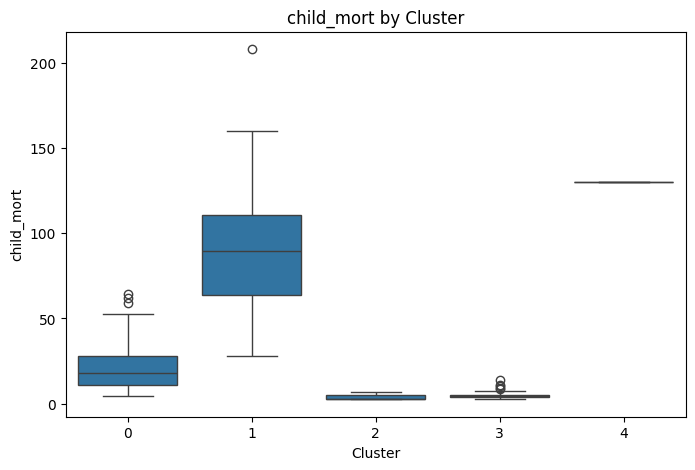

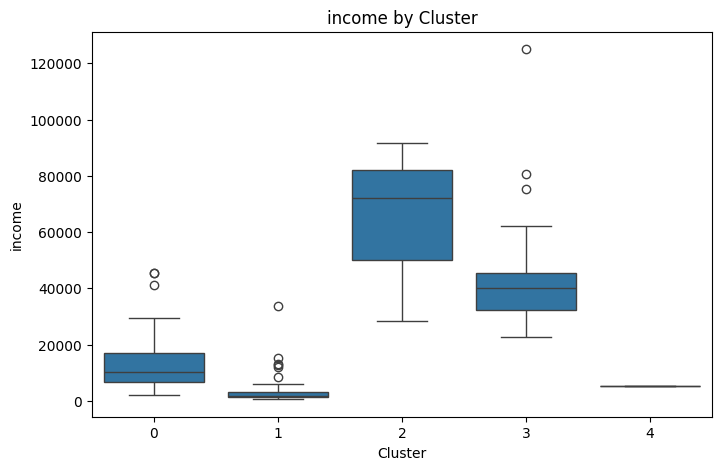

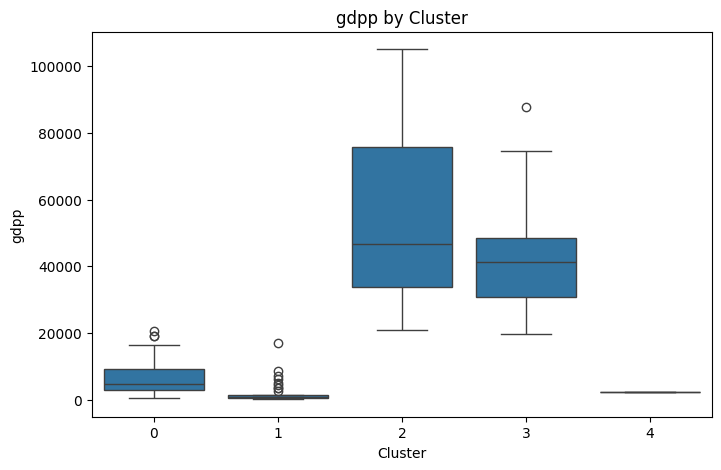

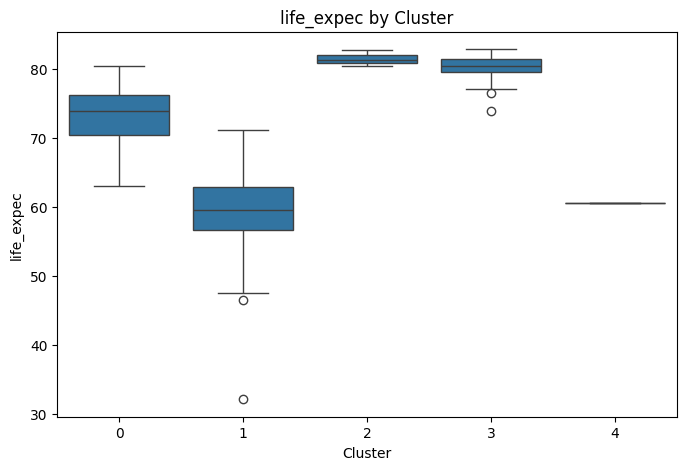


Cluster Centers:
   child_mort     exports    health     imports        income   inflation  \
0   21.614286   40.976060  6.169048   47.518642  12801.071429    7.618857   
1   90.793617   29.661915  6.462553   43.680851   3870.702128    9.951809   
2    4.133333  176.000000  6.793333  156.666667  64033.333333    2.468000   
3    5.181250   46.118750  9.088437   40.584375  44021.875000    2.513844   
4  130.000000   25.300000  5.070000   17.400000   5150.000000  104.000000   

   life_expec  total_fer          gdpp  
0   73.004762   2.277619   6581.809524  
1   59.212766   4.974043   1900.255319  
2   81.433333   1.380000  57566.666667  
3   80.081250   1.788437  42118.750000  
4   60.500000   5.840000   2330.000000  

Results Saved Successfully!
Output File: country_clustering_results.csv

PROJECT COMPLETED SUCCESSFULLY

Interpretation:

Cluster 0
Average Income: 12801.07
Average GDP: 6581.81
Average Child Mortality: 21.61

Cluster 1
Average Income: 3870.70
Average GDP: 1900.26
Average

In [3]:
# ============================================================
# COUNTRY CLUSTERING PROJECT
# K-MEANS + PCA + ELBOW METHOD + SILHOUETTE SCORE
# ============================================================

# Install if required
# !pip install scikit-learn seaborn

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# ============================================================
# 1. LOAD THE CORRECT DATASET
# ============================================================

csv_path = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.lower() == "country-data.csv":
            csv_path = os.path.join(dirname, filename)
            break

if csv_path is None:
    raise FileNotFoundError(
        "Country-data.csv not found. Check dataset attachment."
    )

print("Dataset Found At:")
print(csv_path)

# Load dataset
df = pd.read_csv(csv_path)

# ============================================================
# 2. BASIC DATA EXPLORATION
# ============================================================

print("\nDataset Shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# ============================================================
# 3. PREPARE DATA
# ============================================================

country_names = df["country"]

X = df.drop("country", axis=1)

print("\nFeature Matrix Shape:")
print(X.shape)

# ============================================================
# 4. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("\nScaled Data Shape:")
print(X_scaled.shape)

# ============================================================
# 5. ELBOW METHOD
# ============================================================

wcss = []

for k in range(1, 11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# ============================================================
# 6. SILHOUETTE SCORES
# ============================================================

print("\nSilhouette Scores")

best_score = -1
best_k = 2

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    print(f"K = {k} --> Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print("\nBest K:", best_k)
print("Best Silhouette Score:", round(best_score,4))

# ============================================================
# 7. FINAL KMEANS MODEL
# ============================================================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print("\nCluster Counts:")
print(df["Cluster"].value_counts())

# ============================================================
# 8. PCA DIMENSION REDUCTION
# ============================================================

pca = PCA(n_components=2)

pca_result = pca.fit_transform(X_scaled)

df["PCA1"] = pca_result[:,0]
df["PCA2"] = pca_result[:,1]

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ============================================================
# 9. PCA VISUALIZATION
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    data=df,
    palette="Set1",
    s=120
)

plt.title("Country Clusters using PCA")
plt.show()

# ============================================================
# 10. CLUSTER SUMMARY
# ============================================================

cluster_summary = df.groupby("Cluster").mean(numeric_only=True)

print("\nCluster Summary:")
print(cluster_summary)

# ============================================================
# 11. COUNTRIES IN EACH CLUSTER
# ============================================================

for cluster in sorted(df["Cluster"].unique()):

    print("\n" + "="*60)
    print(f"CLUSTER {cluster}")
    print("="*60)

    countries = df[df["Cluster"] == cluster]["country"]

    for country in countries:
        print(country)

# ============================================================
# 12. TOP COUNTRIES NEEDING AID
# ============================================================

df["Aid_Score"] = (

    df["child_mort"].rank(ascending=False)

    +

    df["income"].rank(ascending=True)

    +

    df["gdpp"].rank(ascending=True)

)

aid_countries = df.sort_values(
    by="Aid_Score",
    ascending=False
)

print("\nTop 10 Countries Needing Aid:\n")

print(
    aid_countries[
        [
            "country",
            "child_mort",
            "income",
            "gdpp"
        ]
    ].head(10)
)

# ============================================================
# 13. FEATURE DISTRIBUTION BY CLUSTER
# ============================================================

important_features = [
    "child_mort",
    "income",
    "gdpp",
    "life_expec"
]

for feature in important_features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        x="Cluster",
        y=feature,
        data=df
    )

    plt.title(f"{feature} by Cluster")

    plt.show()

# ============================================================
# 14. CLUSTER CENTERS
# ============================================================

cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=X.columns
)

print("\nCluster Centers:")
print(cluster_centers)

# ============================================================
# 15. SAVE RESULTS
# ============================================================

output_file = "country_clustering_results.csv"

df.to_csv(
    output_file,
    index=False
)

print("\nResults Saved Successfully!")
print("Output File:", output_file)

# ============================================================
# 16. FINAL INTERPRETATION
# ============================================================

print("\nPROJECT COMPLETED SUCCESSFULLY")

print("\nInterpretation:")

for cluster in sorted(df["Cluster"].unique()):

    cluster_data = df[df["Cluster"] == cluster]

    avg_income = cluster_data["income"].mean()
    avg_gdpp = cluster_data["gdpp"].mean()
    avg_child_mort = cluster_data["child_mort"].mean()

    print(f"\nCluster {cluster}")
    print(f"Average Income: {avg_income:.2f}")
    print(f"Average GDP: {avg_gdpp:.2f}")
    print(f"Average Child Mortality: {avg_child_mort:.2f}")